In [1]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
top_10_skills = df_exploded['job_skills'].value_counts()
top_10_skills

job_skills
sql             384849
python          380909
aws             145381
azure           132527
r               130892
                 ...  
rubyon rails         1
visualbasic          1
gtx                  1
wimi                 1
rocketchat           1
Name: count, Length: 252, dtype: int64

<Axes: title={'center': 'Top 10 Job Skills'}, ylabel='job_skills'>

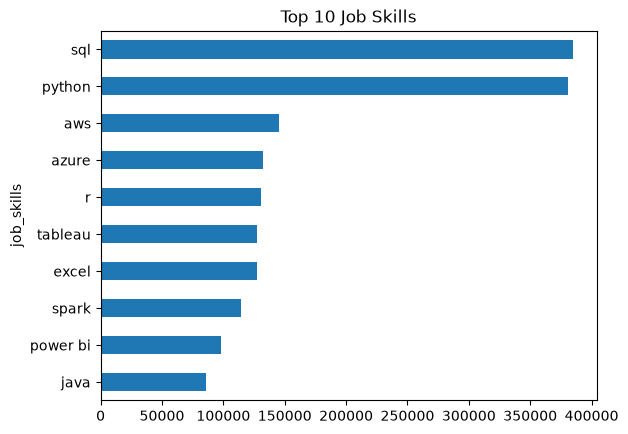

In [3]:
df_exploded = df.explode('job_skills', ignore_index=True).copy()
top_10_skills = df_exploded['job_skills'].value_counts().head(10)
top_10_skills.sort_values(ascending=True).plot(kind='barh', title='Top 10 Job Skills')

In [7]:
skill_count= df_exploded.groupby(['job_title_short','job_skills']).size()

In [19]:
df_skill_count= skill_count.reset_index(name='skill_count').sort_values(by='skill_count', ascending=False)

In [26]:
job_title = 'Data Scientist'
top_skills =15

df_skill_final= df_skill_count[df_skill_count['job_title_short'] == job_title].head(top_skills)

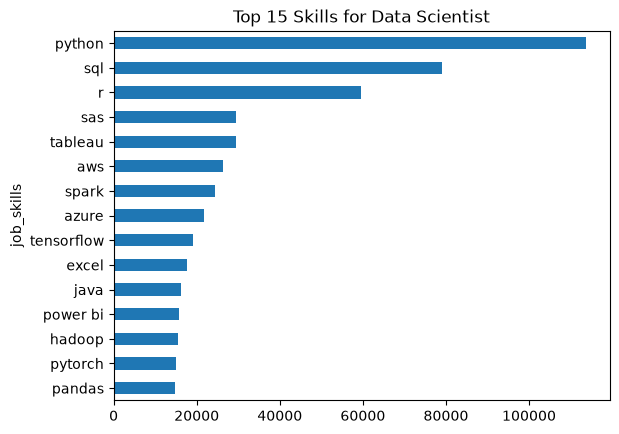

In [27]:
import matplotlib.pyplot as plt
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count', title=f'Top {top_skills} Skills for {job_title}', legend=False)
plt.gca().invert_yaxis()